# ***Prueba de significancia para autocorrelaciones simples***

**Bartlett (1946)** proporciona el siguiente criterio:  
**Aproximaciones para las varianzas y covarianzas de $\hat{\rho}_k$**



Varianza de $\hat{\rho}_k$:

$$
\text{Var}(\hat{\rho}_k) = \frac{1}{N}
\left(
\rho_k^2 + \rho_{j+k} \rho_{k-1} - 4\rho_j \rho_k \rho_{j-k} + 2 \rho_j^2 \rho_k^2
\right)
$$




 Covarianza entre $\hat{\rho}_k$ y $\hat{\rho}_{k+s}$:

$$
\text{Cov}(\hat{\rho}_k, \hat{\rho}_{k+s}) = \frac{1}{N} \sum_{j=0}^\infty \rho_j \rho_{j+s}
$$





**Si el proceso es MA(q)**, de forma que las autocorrelaciones para retardos mayores que $q$ son cero,  
la varianza se convierte a:

$$
\text{Var}(\hat{\rho}_k) =
\frac{1}{N - d}
\left(
1 + 2 \sum_{r=1}^{q} \rho_r^2
\right)
\quad \text{para } k > q
$$




**Es decir**, en la hipótesis de que $\rho_k = 0$ para $k > q$,  
se obtiene la expresión anterior.

En la práctica, esta expresión se utiliza con $\rho_j$ sustituida por su valor estimado  
para $j = 1, \dots, q$.


---

**Ejemplo:**  
Considere la serie $\nabla^2 T(\text{IPC}_t)$, donde $T(\text{IPC}_t)$ corresponde  
a la **transformación de Box–Cox** con $\gamma = -0.999$.

Note que esta serie es $I(2)$;  
sus autocorrelaciones simples muestrales se presentan a continuación.


*al final de la pizarra.*

---

Sabemos que el proceso MA(q) tiene $q$ autocorrelaciones distintas de cero.  
Por otra parte, la expresión para la **varianza de las autocorrelaciones muestrales** es:

$$
\text{Var}(\hat{\rho}_k) =
\frac{1}{N - d} \left( 1 + 2 \sum_{j=1}^{q} \rho_j^2 \right)
\quad \text{para } k > q
$$

---




Se dice que una **autocorrelación simple es significativamente distinta de cero** si:

$$
|\hat{\rho}_k| > 2 \sqrt{
\frac{1}{N - d}
\left( 1 + 2 \sum_{j=1}^{q} \rho_j^2 \right)
}
\quad \text{para } k > q
$$

---




**Ejemplo:**

Supongamos que $\rho_k = 0$ para $k > 0$

Entonces:

$$
|\hat{\rho}_{1}| = 1 - 0.3341 = 0.334
$$


$$
\sqrt{ \text{Var}(\hat{\rho}_k) } =
\sqrt{
\frac{1}{90}
\left( 1 + 2 \sum_{j=1}^{q} \rho_j^2 \right)
} =
\sqrt{ \frac{1}{90} \left( 1 + 2(0) \right) } =
\sqrt{ \frac{1}{90} } = 0.1054
$$


Como $|\hat{\rho}_1| = 0.334$ y $2(0.1054) = 0.2108$,  
podemos **concluir que $\rho_1$ es significativamente distinto de cero**.

---



Supongamos que $\rho_1 \ne 0$ pero $\rho_k = 0$ para $k > 1$.

Si $|\hat{\rho}_2| = 0.156$:



$$
\sqrt{ \text{Var}(\hat{\rho}_2) } =
\sqrt{
\frac{1}{90} \left( 1 + 2(-0.332)^2 \right)
} = 0.116
$$




Entonces:

$$
2 \times 0.116 = 0.233
$$

Como $|\hat{\rho}_2| = 0.156 < 0.233$,  
**no es significativamente diferente de cero**.

---

**Conclusión:**  
Puesto que ninguna autocorrelación muestral con retardo $k \geq 2$ satisface la condición para $q = 1$,  
se concluye que la **única autocorrelación significativamente distinta de cero es $\rho_1$**.


In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from scipy import stats
from statsmodels.tsa.stattools import acf, pacf

pio.renderers.default = "png"

from pizarras.plotly_pages import PlotlyPagesPublisher
publisher = PlotlyPagesPublisher(
    github_username="nuriaarroyo",
    github_repo="ecoII",
    pages_root="docs",
)


In [2]:
import pandas as pd
# =========================
ipc = pd.read_csv('pizarras/parcial2/IPC.csv')
ipc_values = ipc['IPC'].values

In [3]:
def stem_trace(x, y, line_width=2, marker_size=7):
    xs, ys = [], []
    for xi, yi in zip(x, y):
        xs += [xi, xi, None]
        ys += [0, yi, None]

    lines = go.Scatter(
        x=xs, y=ys,
        mode="lines",
        line=dict(width=line_width),
        showlegend=False,
        hoverinfo="skip",
    )
    dots = go.Scatter(
        x=x, y=y,
        mode="markers",
        marker=dict(size=marker_size),
        showlegend=False,
    )
    return lines, dots


In [4]:
def plot_ipc_boxcox_diff2_acf_pacf_project(
    ipc_values,
    start_year=1970,
    freq=4,
    lambda_bc=-1,
    nlags=20,
    pacf_method="ywm",
    ci_fixed=0.20,           # you used ~0.20 in screenshots
):

    x = np.asarray(ipc_values, dtype=float)

    # Box–Cox λ = −1
    y_bc = stats.boxcox(x, lmbda=lambda_bc)
    y = np.diff(y_bc, n=2)

    acf_vals  = acf(y, nlags=nlags, fft=False)
    pacf_vals = pacf(y, nlags=nlags, method=pacf_method)

    lags = np.arange(0, nlags + 1)
    lag_years = lags / freq

    fig = make_subplots(
        rows=1, cols=2,
        horizontal_spacing=0.12,
        subplot_titles=("IPC", "Series  BoxCoxIPCdifff2"),
    )

    # ---- ACF
    acf_lines, acf_dots = stem_trace(lag_years, acf_vals)
    fig.add_trace(acf_lines, row=1, col=1)
    fig.add_trace(acf_dots,  row=1, col=1)

    # ---- PACF
    pacf_lines, pacf_dots = stem_trace(lag_years[1:], pacf_vals[1:])
    fig.add_trace(pacf_lines, row=1, col=2)
    fig.add_trace(pacf_dots,  row=1, col=2)

    # ---- Baselines + CI (PROJECT STYLE)
    for c in (1, 2):
        fig.add_hline(
            y=0,
            line_width=1,
            row=1, col=c
        )
        fig.add_hline(
            y=ci_fixed,
            line_width=2,
            line_dash="dash",
            row=1, col=c
        )
        fig.add_hline(
            y=-ci_fixed,
            line_width=2,
            line_dash="dash",
            row=1, col=c
        )

    # ---- Axes
    fig.update_xaxes(title_text="Lag", row=1, col=1)
    fig.update_xaxes(title_text="Lag", row=1, col=2)
    fig.update_yaxes(title_text="ACF", row=1, col=1)
    fig.update_yaxes(title_text="Partial ACF", row=1, col=2)

    # ---- Ranges (tight, project-like)
    ymin = min(acf_vals.min(), pacf_vals.min(), -ci_fixed) - 0.05
    ymax = max(acf_vals.max(), pacf_vals.max(),  ci_fixed) + 0.05
    fig.update_yaxes(range=[ymin, ymax], row=1, col=1)
    fig.update_yaxes(range=[ymin, ymax], row=1, col=2)

    # ---- Layout (ecoII / pizarras style)
    fig.update_layout(
        template="simple_white",
        height=520,
        width=980,
        showlegend=False,
        margin=dict(l=50, r=30, t=70, b=40),
        title="pizarra 16",
    )


    return fig


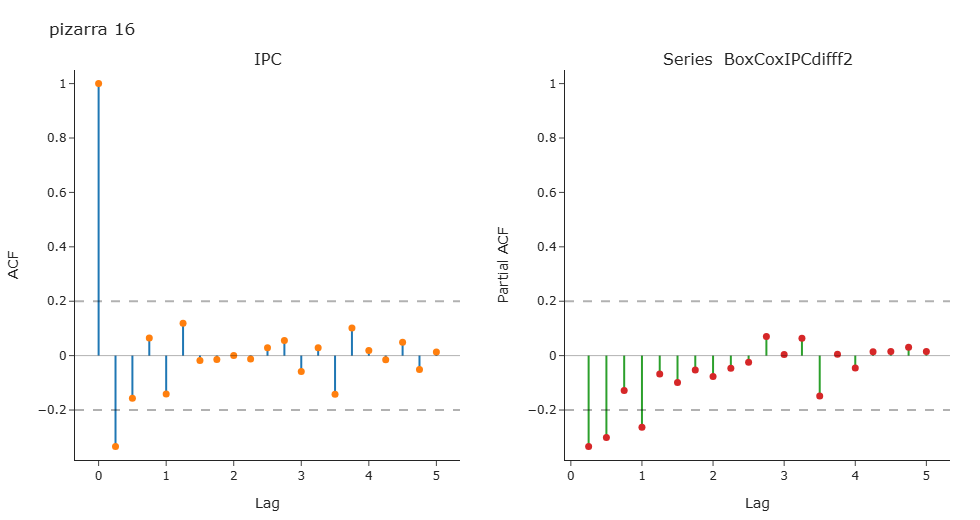

'https://nuriaarroyo.github.io/ecoII/interactive/pizarra_16.html'

In [5]:
fig = plot_ipc_boxcox_diff2_acf_pacf_project(
    ipc_values,
    start_year=1970,
    freq=4,
    lambda_bc=-1,
    nlags=20
)

fig.show()

out_path, public_url, pdf_url = publisher.save_html(
    fig,
    site_subfolder="interactive",
    print_link=False,
)

pdf_url